In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

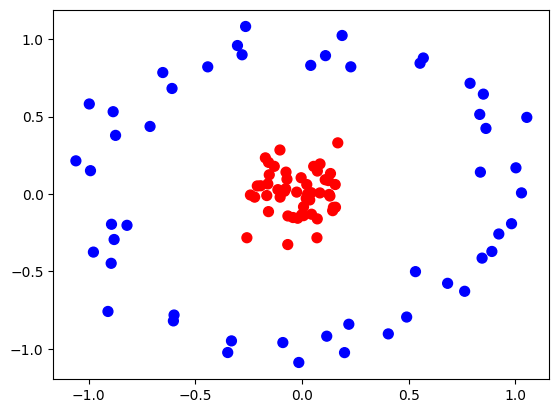

In [13]:
from sklearn.datasets._samples_generator import make_circles
X,y = make_circles(100,factor=.1,noise=.1)

plt.scatter(X[:,0],X[:,1], c=y,s=50,cmap='bwr')

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.55

In [15]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_31900\2064171096.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


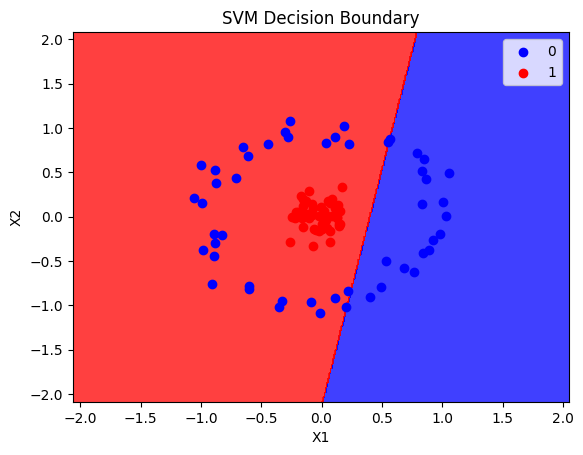

In [16]:
plot_decision_boundary(X, y, classifier)

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

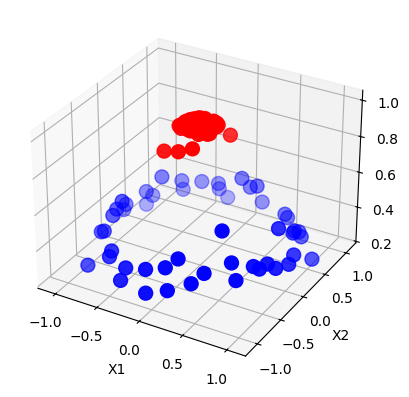

In [17]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax
plot_3d_plot(X,y)

In [18]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train,y_train)
y_pred = rbf_classifier.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

C:\Users\hp\AppData\Local\Temp\ipykernel_31900\2064171096.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


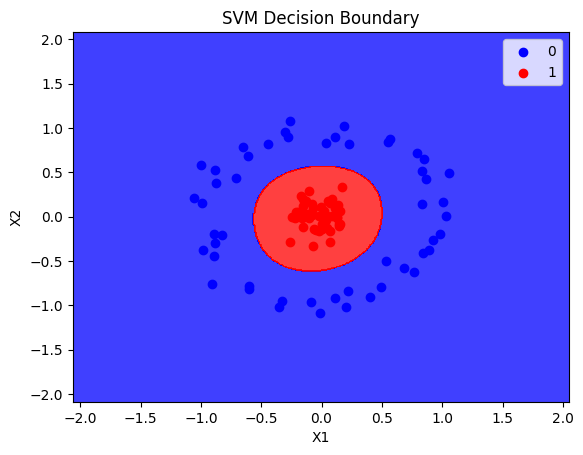

In [19]:

plot_decision_boundary(X, y, rbf_classifier)

In [30]:
rbf_classifier = SVC(kernel="poly",degree=4)
rbf_classifier.fit(X_train,y_train)
y_pred = rbf_classifier.predict(X_test)
accuracy_score(y_test,y_pred)

0.95

C:\Users\hp\AppData\Local\Temp\ipykernel_31900\2064171096.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


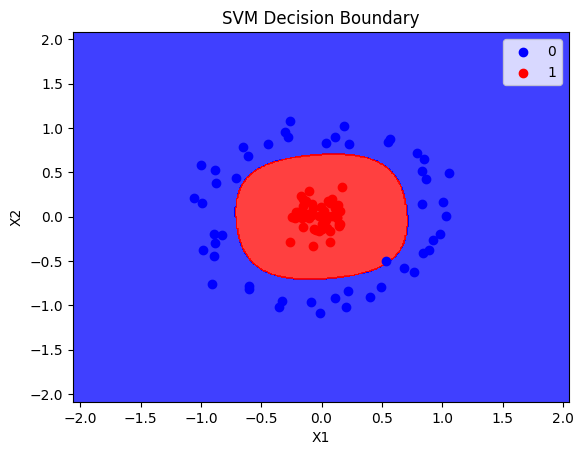

In [31]:
plot_decision_boundary(X, y, rbf_classifier)

In [32]:
X

array([[ 1.94822459e-02, -2.82010668e-02],
       [ 1.67429912e-01,  3.30597445e-01],
       [ 4.06562104e-02,  8.30939112e-01],
       [-1.71969642e-01,  2.33655953e-01],
       [ 2.59746080e-02,  2.81279027e-04],
       [ 4.44096504e-02, -1.30406537e-01],
       [-1.13300735e-01,  2.82709345e-02],
       [-2.58669547e-01, -2.82364503e-01],
       [ 1.08516201e-01,  9.24801185e-02],
       [ 1.26974787e-01, -2.87178731e-03],
       [-9.01005303e-02, -9.59327360e-01],
       [-7.52895827e-02,  1.41439948e-01],
       [ 1.55329723e-01,  6.14726911e-02],
       [ 1.33174192e-01,  1.32459771e-01],
       [-2.05602812e-02, -1.56406194e-01],
       [-2.09812676e-01,  5.22485452e-02],
       [ 1.05350326e+00,  4.95094656e-01],
       [-1.97641309e-03, -1.34264536e-01],
       [-3.02811603e-01,  9.59120147e-01],
       [-2.81162805e-01,  8.99407551e-01],
       [ 1.23344925e-01,  8.68570231e-02],
       [-8.81065932e-01, -2.93743656e-01],
       [ 1.09847970e-01,  8.93901132e-01],
       [ 8.

In [33]:
np.exp(-(X**2)).sum(1)

array([1.99882553, 1.86882271, 1.49969393, 1.91772791, 1.99932547,
       1.98116765, 1.98644606, 1.85864532, 1.97977719, 1.98399843,
       1.39031068, 1.97454103, 1.97238965, 1.96502842, 1.97541126,
       1.95420733, 1.11221372, 1.98213064, 1.31093783, 1.36932396,
       1.97738542, 1.3774482 , 1.43775781, 1.33305909, 1.91156793,
       1.9829328 , 1.45826689, 1.46987776, 1.96133011, 1.30587401,
       1.97291277, 1.14509414, 1.99316685, 1.96268411, 1.98898356,
       1.36266236, 1.31573777, 1.94307909, 1.93463717, 1.08266257,
       1.97306226, 1.95582326, 1.91841914, 1.34707884, 1.98585103,
       1.24053938, 1.33192416, 1.31132307, 1.29137401, 1.97123096,
       1.22621204, 1.13735414, 1.98063093, 1.89446526, 1.96559218,
       1.25291328, 1.3448275 , 1.99294942, 1.34518143, 1.47740513,
       1.97029143, 1.33175087, 1.9992167 , 1.99575737, 1.23628902,
       1.99296756, 1.53157968, 1.24233087, 0.99950655, 1.26727656,
       1.18598115, 1.99807377, 1.32454737, 1.31816904, 1.41276

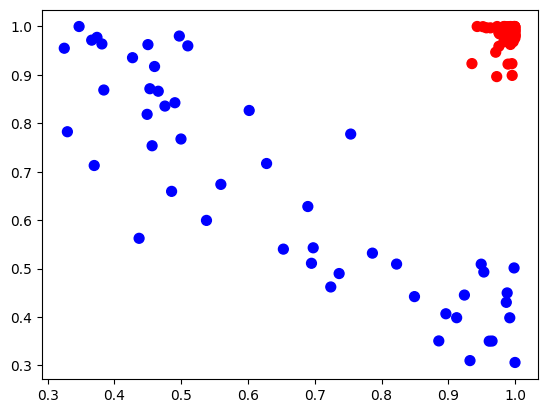

In [35]:
X_new = np.exp(-(X**2))
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')